In [1]:
import tensorflow as tf
print(tf.__version__)


2.15.0


In [2]:
import os

In [3]:
os.path.expanduser("~")

'C:\\Users\\Ideapad 3'

In [4]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.15.0
GPU available: []


In [5]:
from tensorflow import keras

In [6]:
from keras.applications.vgg16 import VGG16
from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input, decode_predictions
import numpy as np

In [7]:
model = VGG16(weights='imagenet')

In [8]:
model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [9]:
!DIR

 Volume in drive G is Movie
 Volume Serial Number is FE7F-4665

 Directory of g:\University of Tehran\Deep learning\Clip

07/18/2026  11:27 PM    <DIR>          .
07/13/2026  09:42 PM    <DIR>          ..
06/14/2026  12:41 AM            14,537 1 .docx
07/18/2026  01:17 AM         2,570,670 3065386.pdf
07/16/2026  11:11 PM            29,506 Alright in the previous video we have relized that when we have more epocs our model going to be overfitting.docx
07/17/2026  06:26 PM       101,848,182 CNN data augumentation.mp4
07/14/2026  01:55 AM       151,520,244 CNN.mp4
07/13/2026  10:47 PM            30,488 First we import keras from tenserflow.docx
07/13/2026  09:46 PM                63 kaggle.json
07/15/2026  11:49 PM            34,574 Part 1.docx
07/17/2026  03:15 PM            21,293 Part 2.docx
07/18/2026  07:03 PM            11,795 Realtime-VGG16-Webcam-Classifier.ipynb
07/18/2026  11:27 PM            12,105 test.ipynb
07/18/2026  06:44 PM            50,230 wolf.jpg
              12 Fil

In [10]:
!activate tf


(tf_env) g:\University of Tehran\Deep learning\Clip>conda.bat activate tf 



EnvironmentNameNotFound: Could not find conda environment: tf
You can list all discoverable environments with `conda info --envs`.




In [11]:
pip install pillow

Note: you may need to restart the kernel to use updated packages.


In [12]:
import keras.utils as image

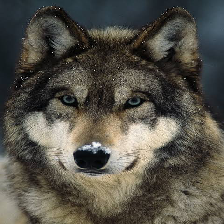

In [13]:
image.load_img('wolf.jpg', target_size=(224, 224))

In [14]:
img = image.load_img('wolf.jpg', target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)


In [15]:
p = model.predict(x)

1/1 [==============================] - 0s 465ms/step


In [16]:
np.sum(p)

1.0000002

In [17]:
p.shape

(1, 1000)

In [18]:
np.max(p)

0.55845445

In [19]:
np.argmax(p)

269

In [20]:
decode_predictions(p, top=7)[0]

[('n02114367', 'timber_wolf', 0.55845445),
 ('n02114712', 'red_wolf', 0.26037106),
 ('n02115641', 'dingo', 0.1366517),
 ('n02114855', 'coyote', 0.022428943),
 ('n02114548', 'white_wolf', 0.015511024),
 ('n02120505', 'grey_fox', 0.0030772618),
 ('n02115913', 'dhole', 0.0026554235)]

In [22]:
import cv2

In [23]:
import matplotlib.pyplot as plt

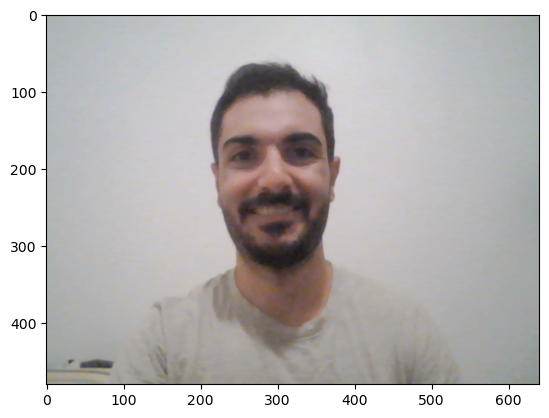

In [39]:
cap = cv2.VideoCapture(0)

success, frame = cap.read()

plt.imshow(frame[:,:,::-1])

cap.release()

In [40]:
cap = cv2.VideoCapture(0)

while True:
    success, frame = cap.read()
    if not success:
        break

    # Preprocess the frame for VGG16
    img = cv2.resize(frame, (224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    # Make predictions
    p = model.predict(x)
    decoded_predictions = decode_predictions(p, top=1)[0]
    
    # Get the class label and probability
    class_label = decoded_predictions[0][1]
    probability = decoded_predictions[0][2]

    # Display the class label and probability on the frame
    cv2.putText(frame, f"{class_label}: {probability:.2f}", (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    # Show the frame
    cv2.imshow('Webcam Classifier', frame)

    # Break the loop on 'q' key press
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

1/1 [==============================] - 0s 152ms/step


Ref:
https://www.manning.com/books/deep-learning-with-python-third-edition

https://class.vision/